In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import json

In [38]:
def read_csv_folder_dict(folder_path):
    """Return a dictionary with filenames as keys."""
    csv_files = list(Path(folder_path).glob('*.csv'))
    csv_files.sort()
    return {file.stem: pd.read_csv(file) for file in csv_files}


def read_json_folder(folder_path):
    """Read all JSON files from a folder into a dict of objects."""
    json_files = list(Path(folder_path).glob('*.json'))
    json_files.sort()
    json_dict = {file.stem: json.load(open(file)) for file in json_files}
    return json_dict


results_dfs = read_csv_folder_dict('./../../data/experiment_output/fair_irl/exp_results/')
info_jsons = read_json_folder('./../../data/experiment_output/fair_irl/exp_info/')

organized_data = defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
organized_info = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

for filename in results_dfs:
    dataset = info_jsons[filename]["DATASET"]
    expert = info_jsons[filename]["EXPERT_ALGO"]
    bias_types = info_jsons[filename]["BIAS_TYPES"]
    organized_data[dataset][expert][tuple(bias_types)] = results_dfs[filename]
    organized_info[dataset][expert][tuple(bias_types)].append(info_jsons[filename])

# Average across all trials for each dataset, expert, and bias type
averaged_data = defaultdict(lambda: defaultdict(lambda: defaultdict(pd.DataFrame)))
averaged_info = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))
for dataset in organized_info:
    for expert in organized_info[dataset]:
        for bias_types in organized_info[dataset][expert]:
            trial_data = organized_data[dataset][expert][bias_types]
            average_series = trial_data.mean()
            averaged_data[dataset][expert][bias_types] = average_series
            averaged_info[dataset][expert][bias_types] = organized_info[dataset][expert][bias_types][0]

In [39]:
unbiased_types = ()
biased_types = ("perfectly_balanced_redlining",)
wL_prefix = "wL_"
exclude_metrics = ["_NR_"]
measurable_experts = ["OptAcc", "HardtDemPar", "HardtEqOpp", "HardtTNRPar", "HardtFPRPar", "HardtFNRPar"]
measurable_metrics = ["Acc", "DemPar", "EqOpp", "TNRPar", "FPRPar", "FNRPar"]
measurable_weights = [wL_prefix + metric for metric in measurable_metrics]

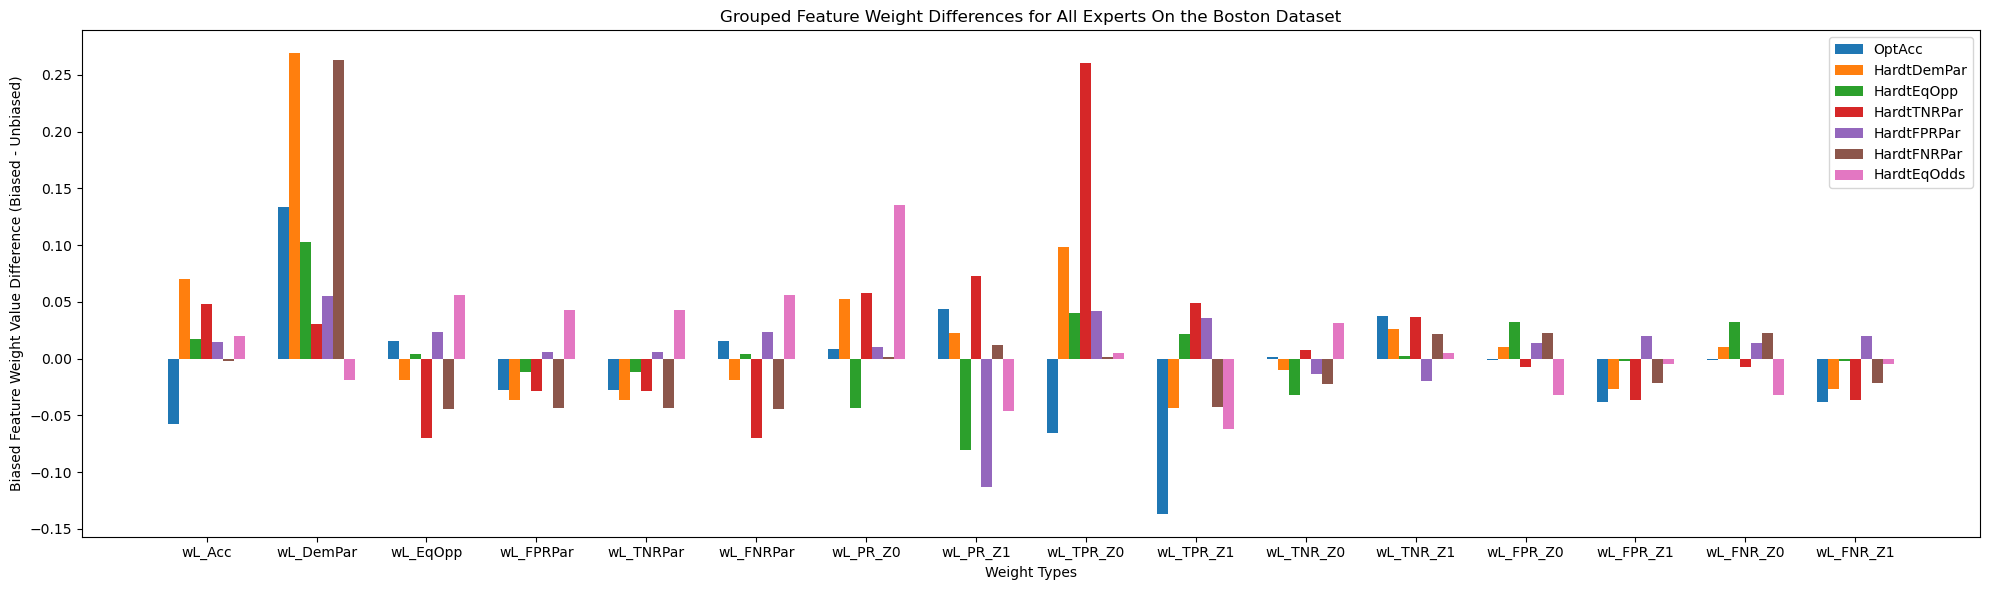

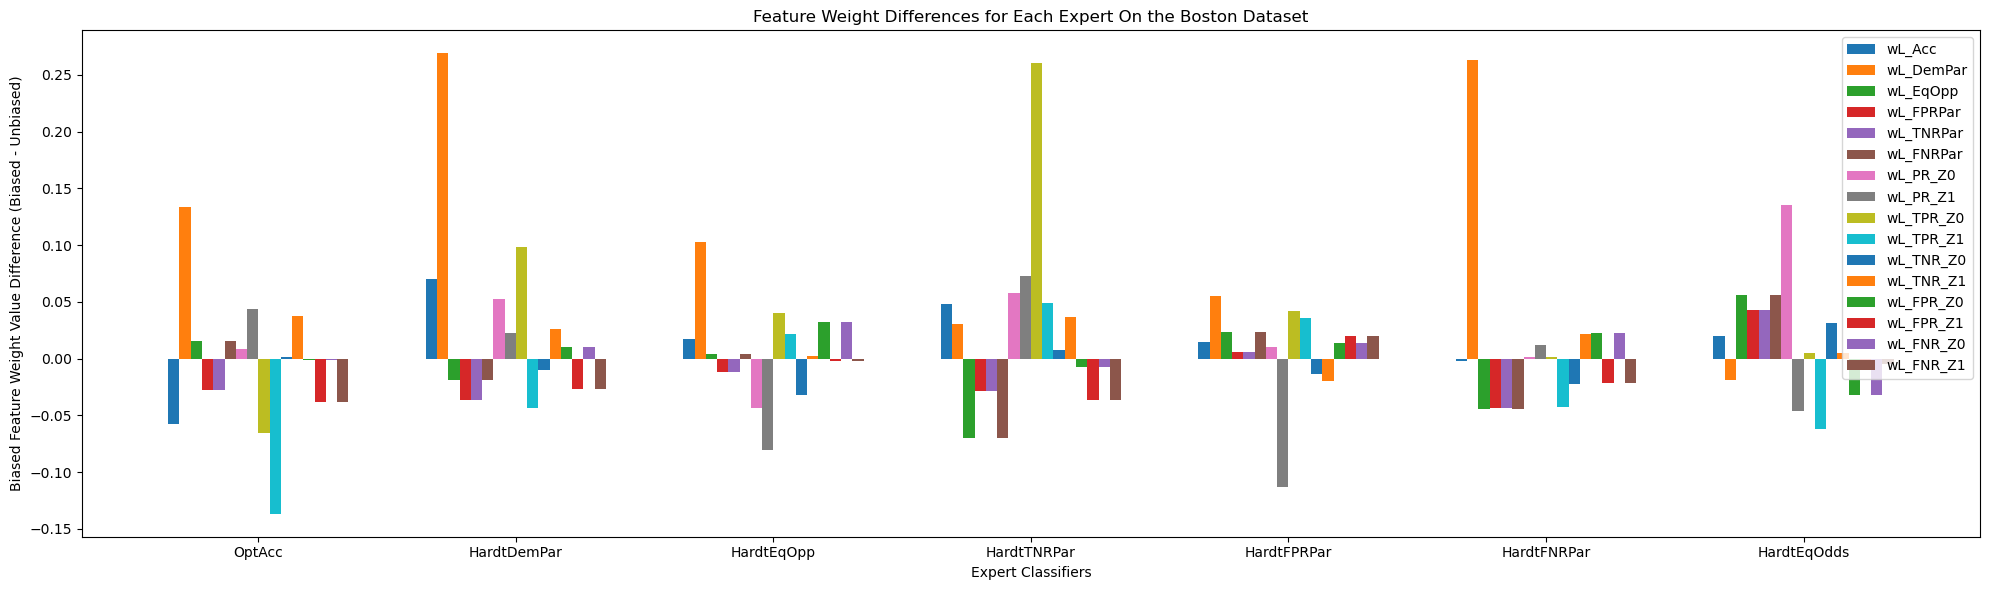

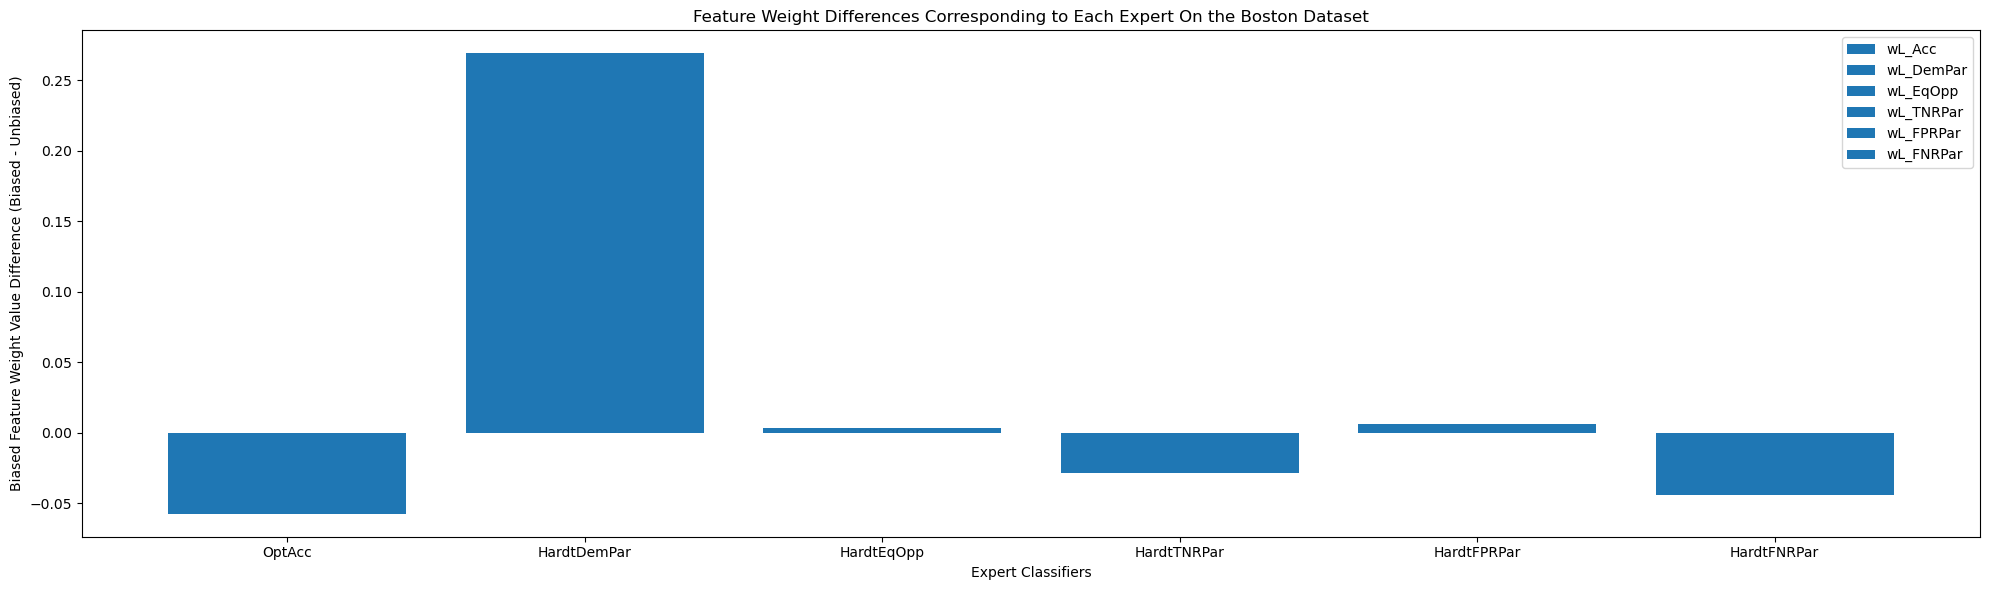

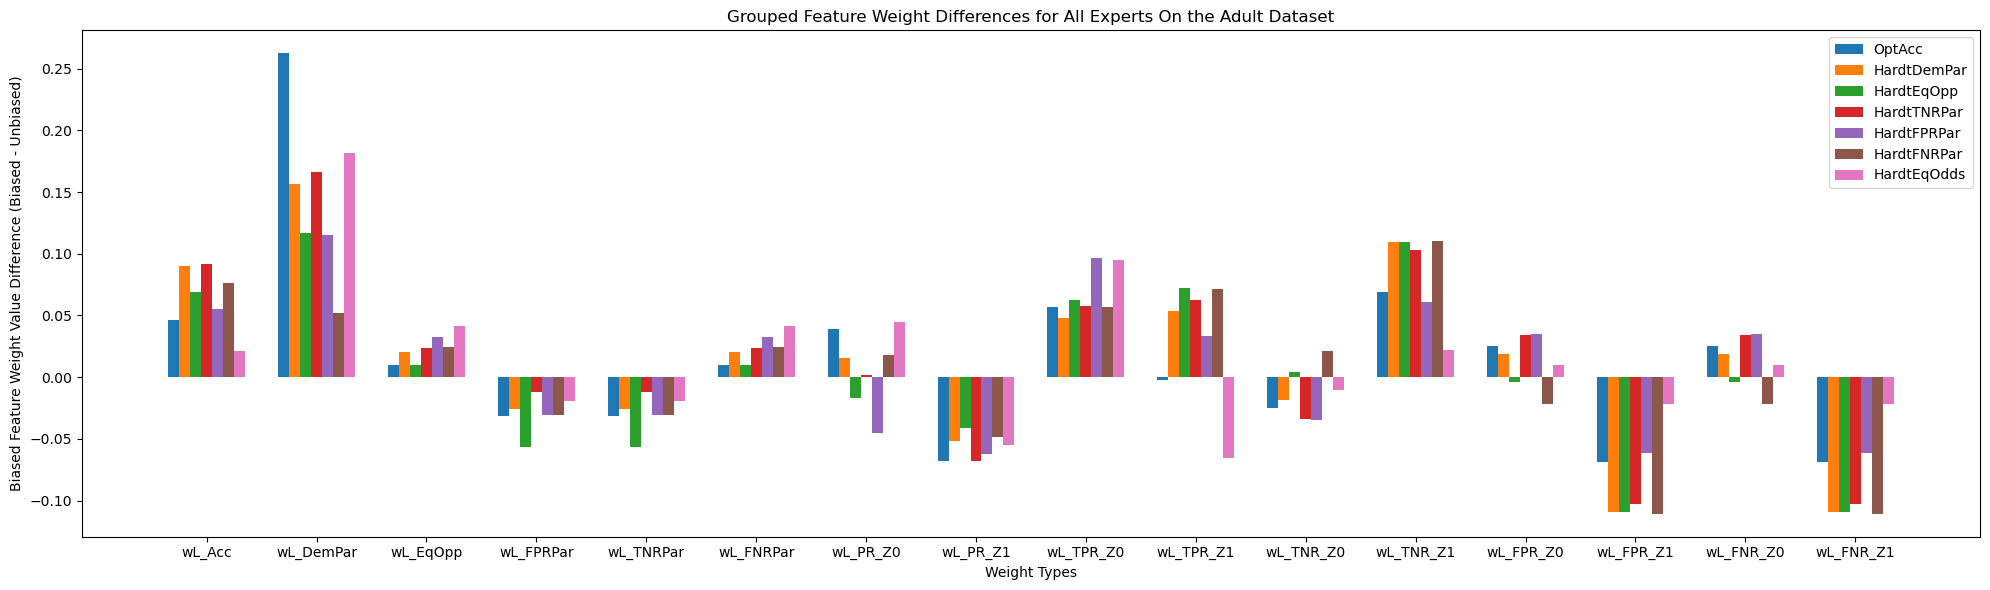

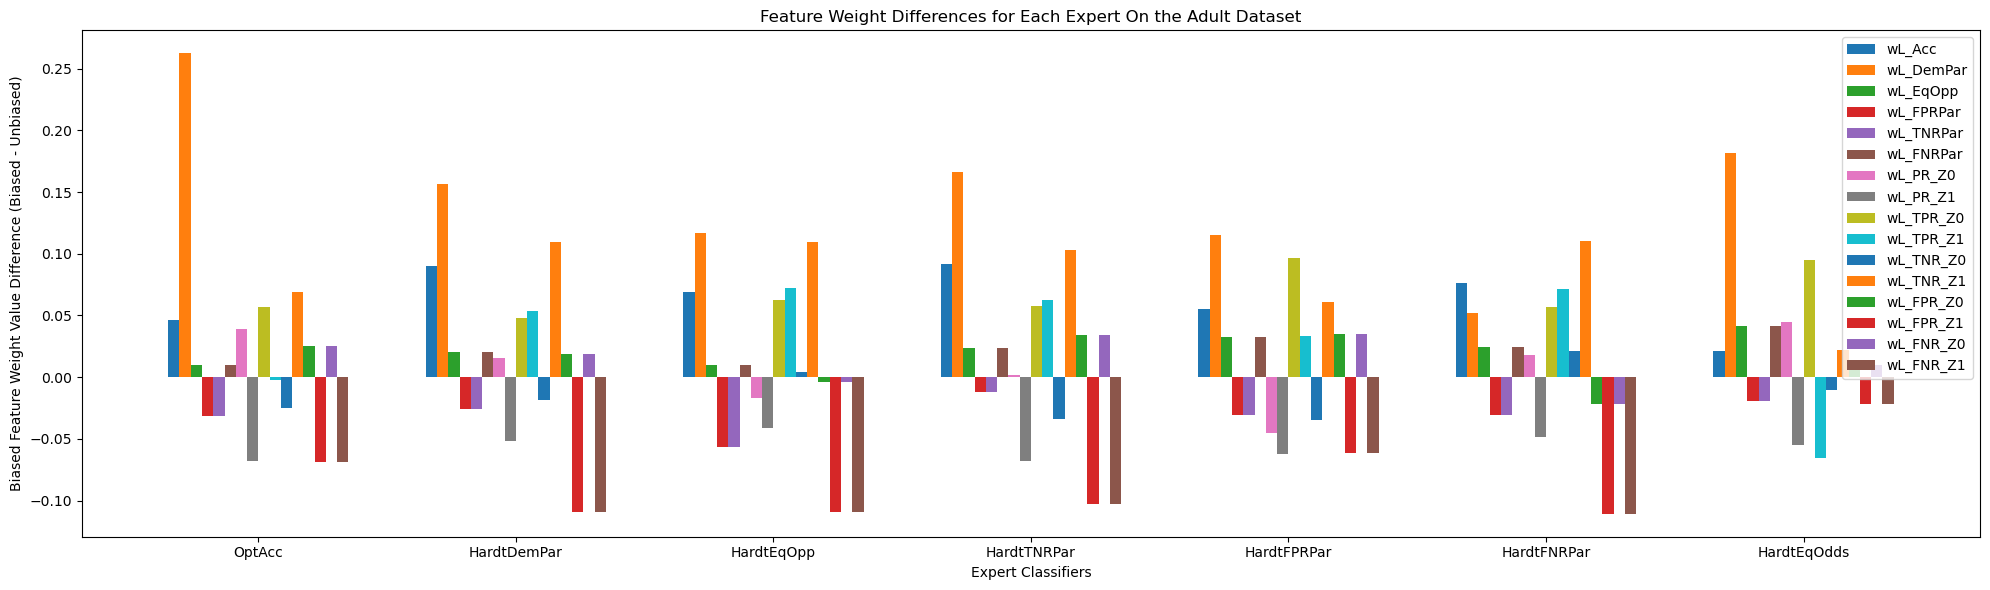

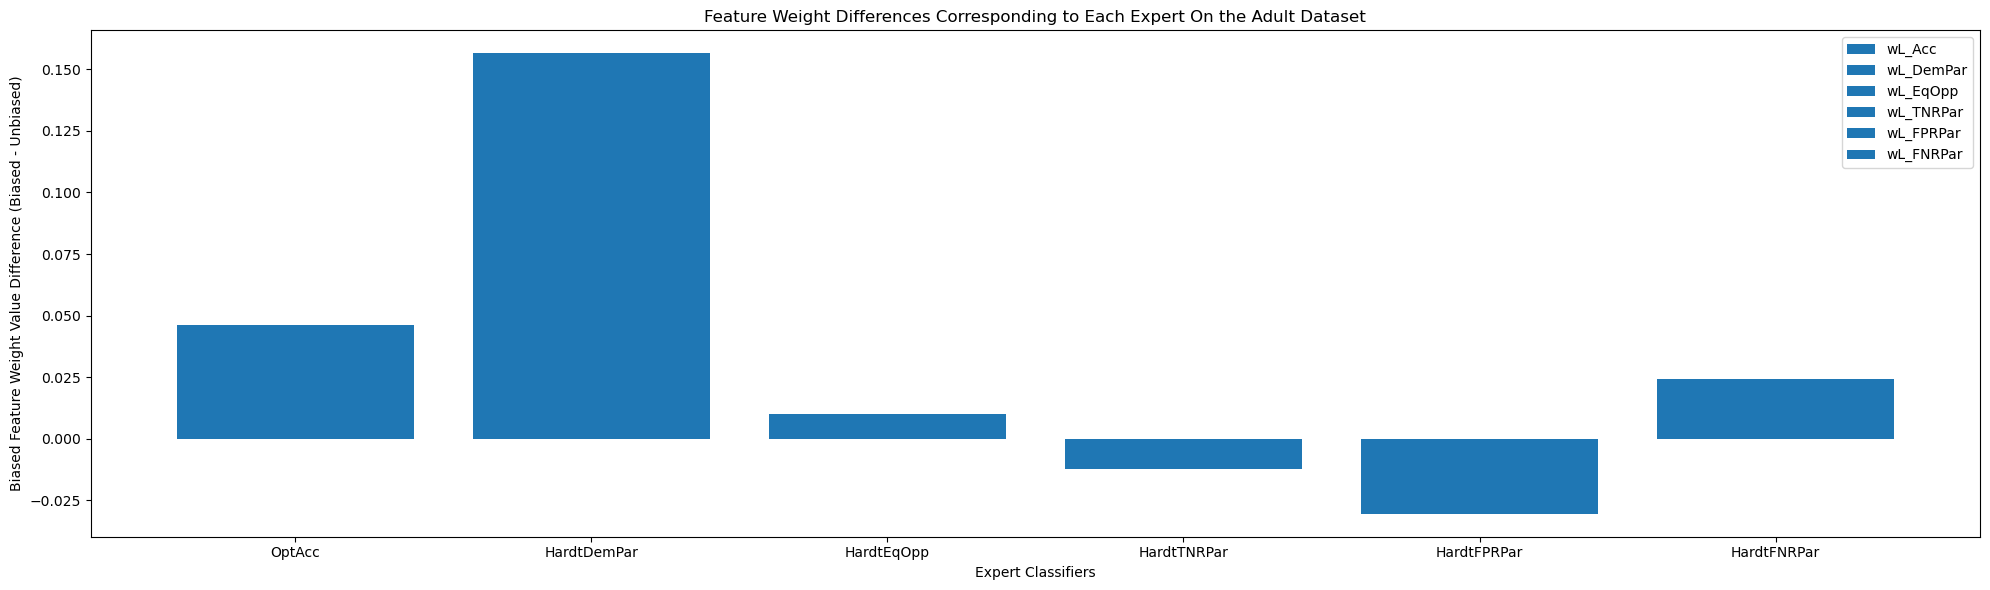

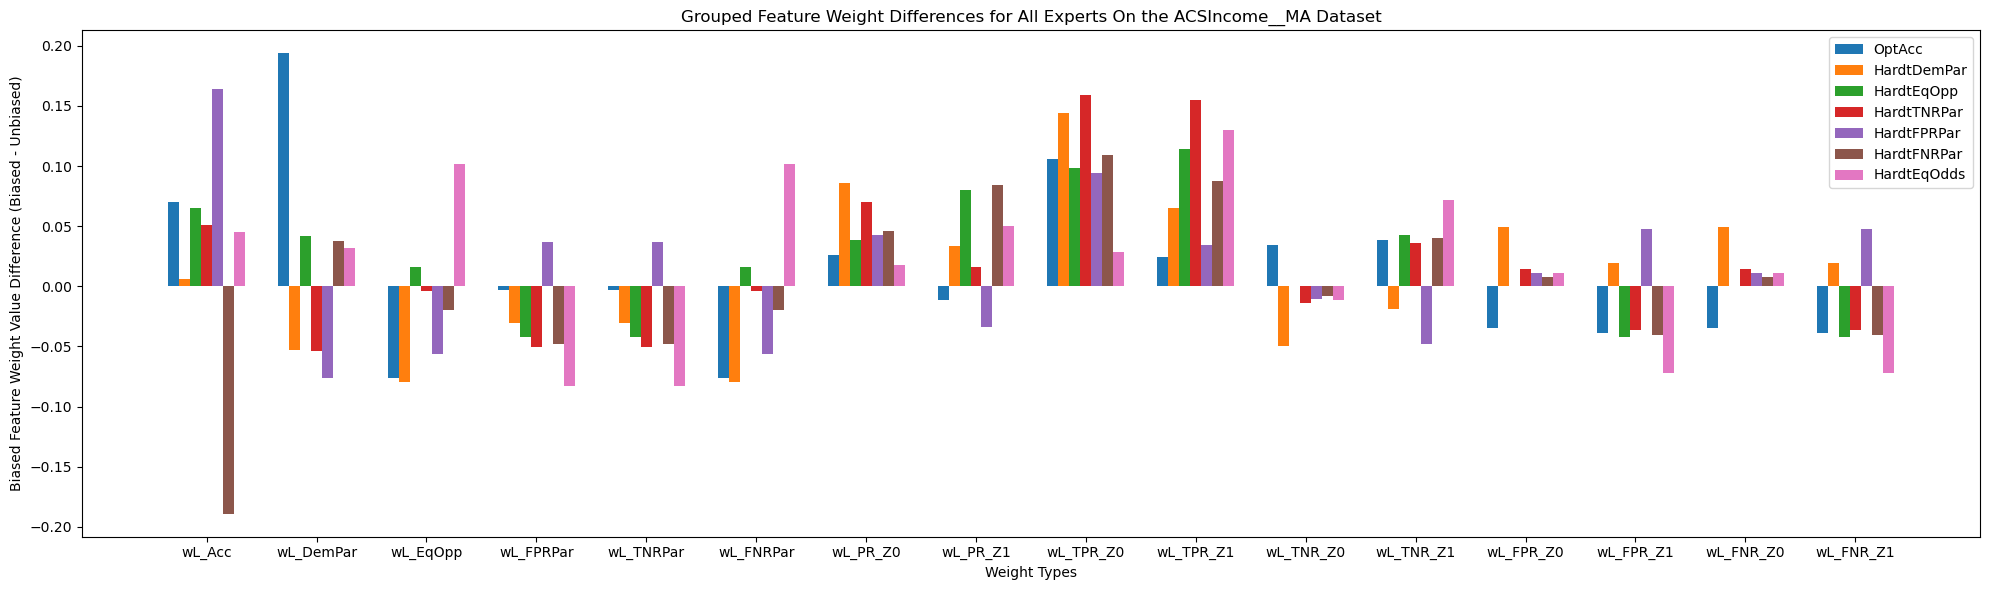

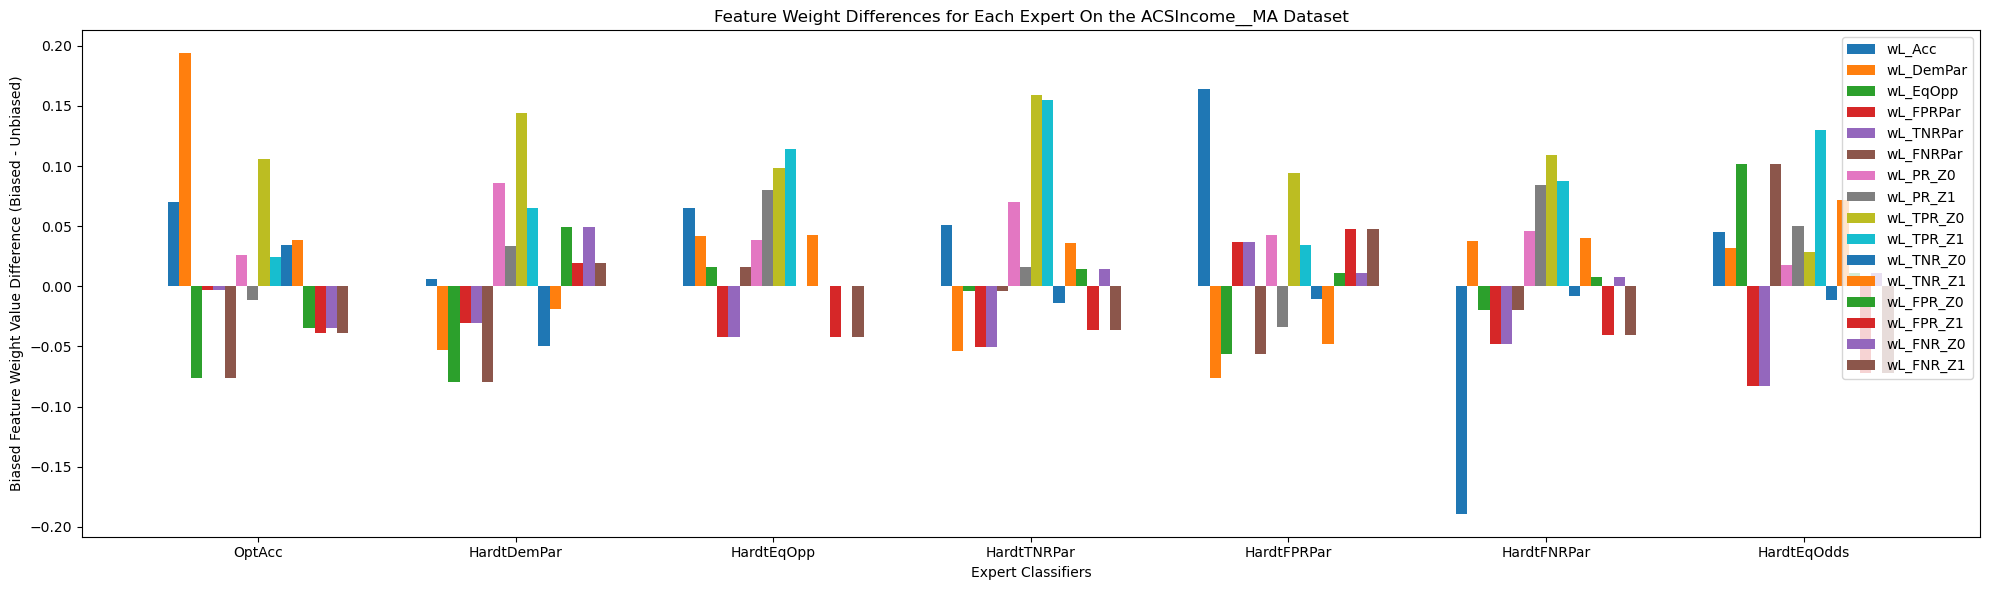

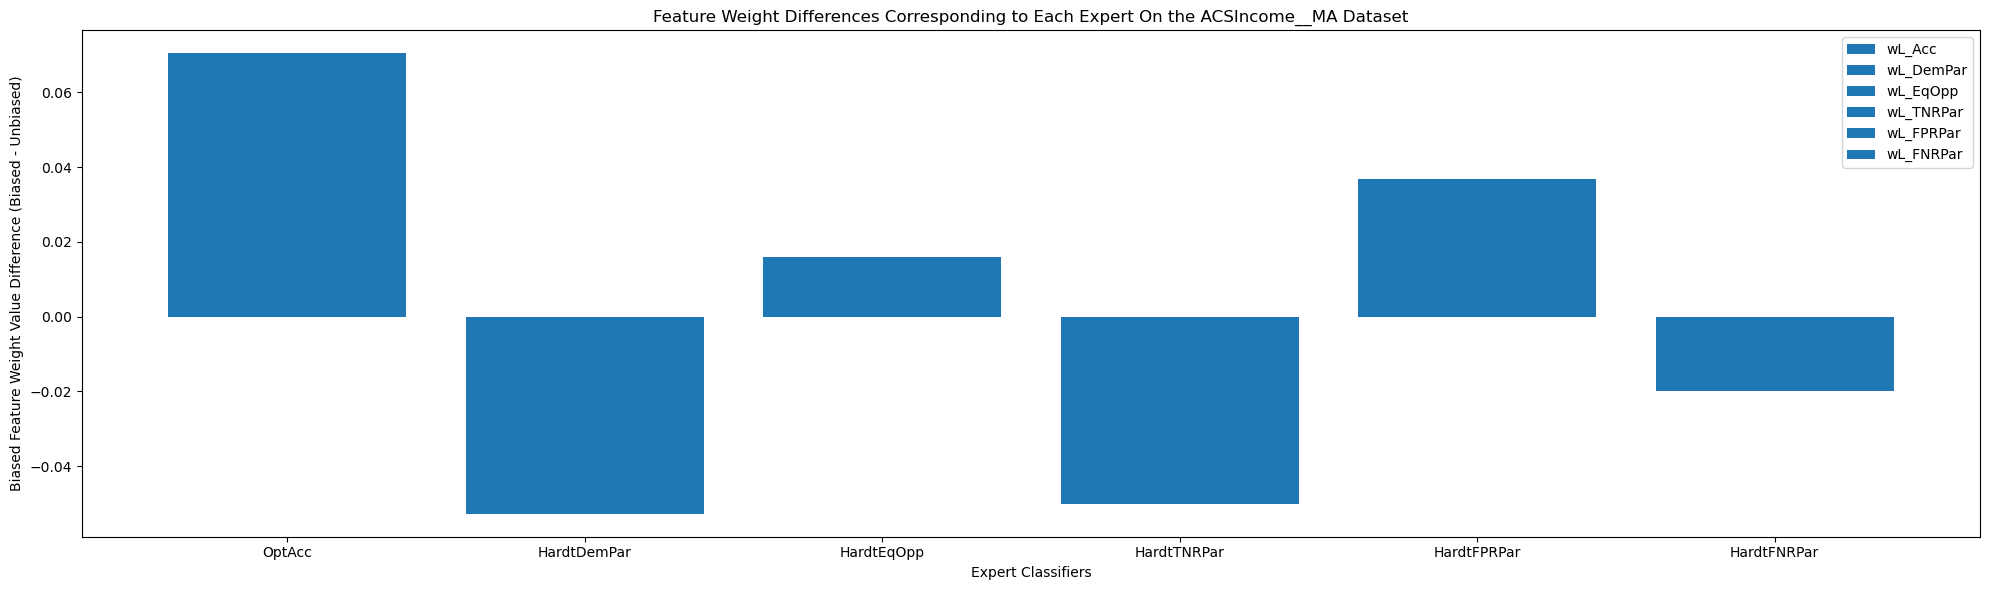

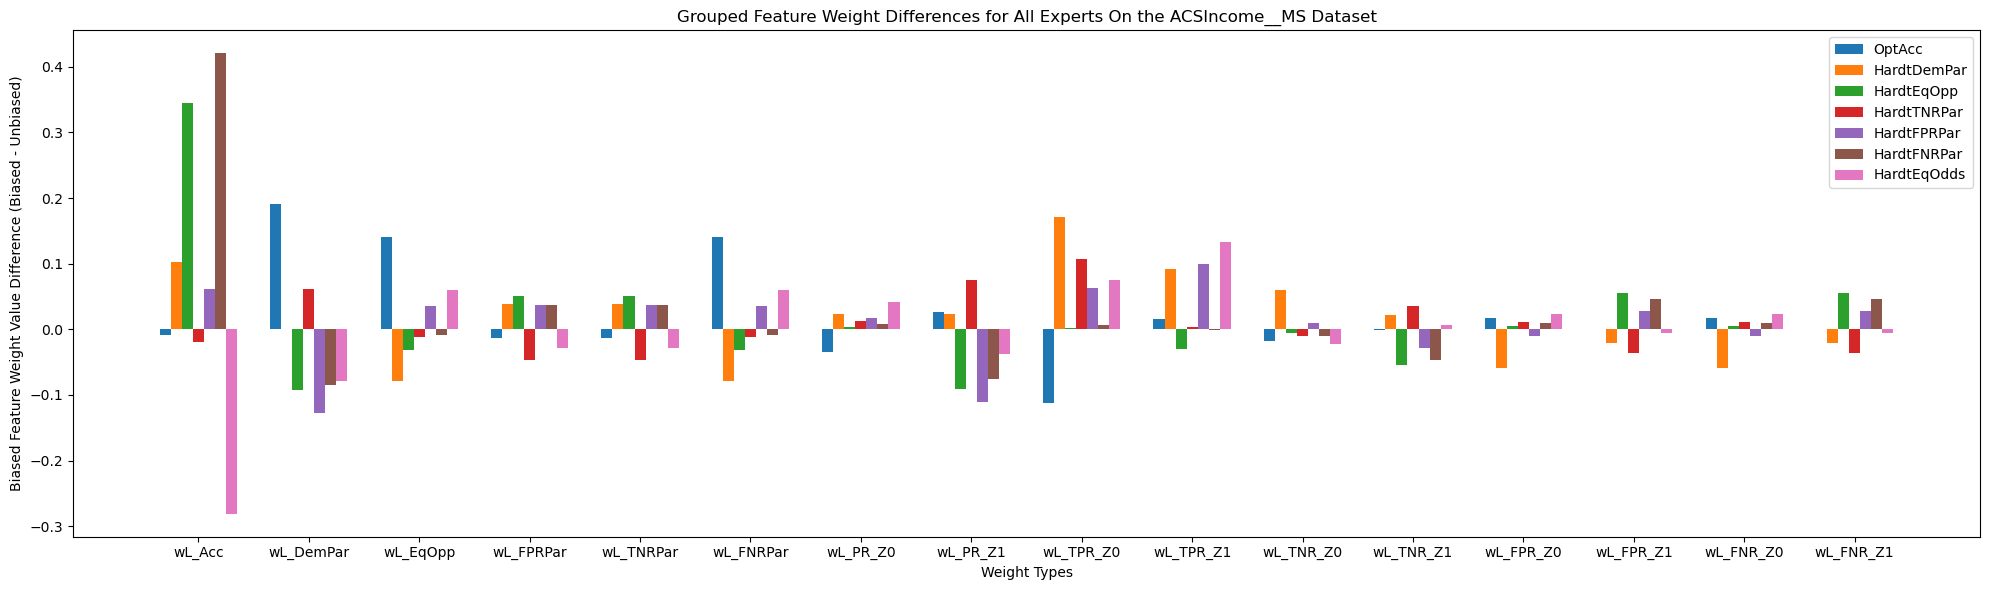

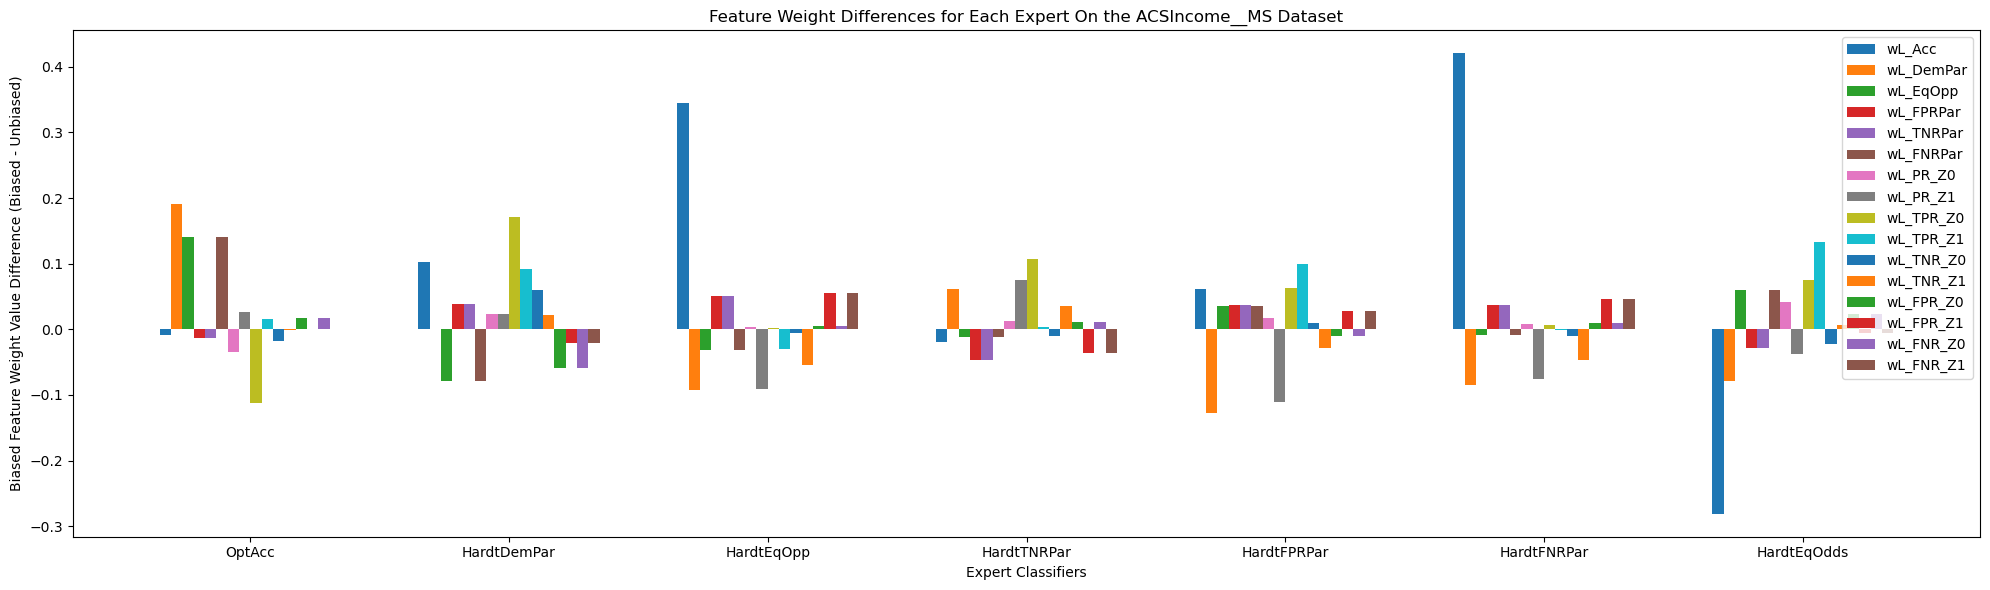

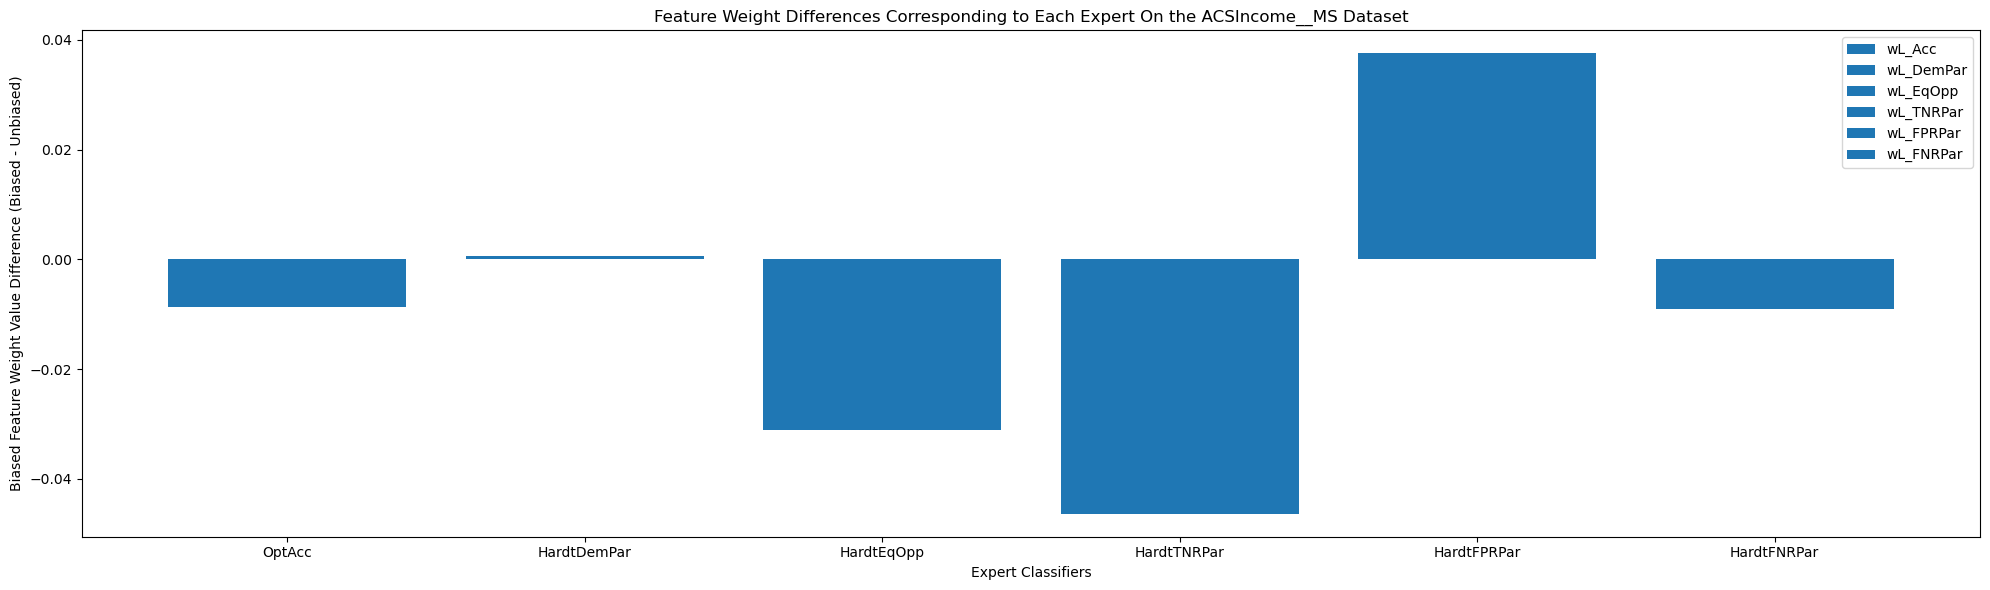

In [40]:
for dataset in averaged_info:
    expert_list = []
    diff_wL_list = []
    for expert in averaged_info[dataset]:
        expert_list.append(expert)
        unbiased_series = averaged_data[dataset][expert][unbiased_types]
        biased_series = averaged_data[dataset][expert][biased_types]
        # diff_series = biased_series.sub(unbiased_series)
        diff_series = biased_series
        index_to_drop = [ind for ind in diff_series.index if any(string in ind for string in exclude_metrics)]
        filtered_diff_series = diff_series.drop(index_to_drop)
        wL_inds = [ind for ind in filtered_diff_series.index if ind.startswith(wL_prefix)]
        diff_wL_series = filtered_diff_series[wL_inds]
        diff_wL_list.append(diff_wL_series)
    
    col_names = diff_wL_list[0].index.tolist()
    
    fig, ax = plt.subplots(figsize=(20, 6))
    
    num_arrays = len(diff_wL_list)
    array_length = len(diff_wL_list[0].index)

    indices = np.arange(array_length)

    bar_width = 0.7 / num_arrays

    for i, arr in enumerate(diff_wL_list):
        ax.bar(indices + i * bar_width, arr.to_numpy(), width=bar_width, label=expert_list[i])

    ax.set_xlabel("Weight Types")
    ax.set_ylabel("Biased Feature Weight Value Difference (Biased - Unbiased)")
    ax.set_title(f'Grouped Feature Weight Differences for All Experts On the {dataset} Dataset')
    ax.set_xticks(indices + bar_width * (num_arrays - 1) / 2)
    ax.set_xticklabels(col_names)
    ax.legend()

    plt.tight_layout()
    plt.show()


    trans_diff_wL_list = np.array(diff_wL_list)
    trans_diff_wL_list = trans_diff_wL_list.T
    trans_diff_wL_list = [trans_diff_wL_list[i] for i in range(trans_diff_wL_list.shape[0])]
    
    fig, ax = plt.subplots(figsize=(20, 6))

    indices = np.arange(num_arrays)

    bar_width = 0.7 / array_length

    for i, arr in enumerate(trans_diff_wL_list):
        ax.bar(indices + i * bar_width, arr, width=bar_width, label=col_names[i])

    ax.set_xlabel("Expert Classifiers")
    ax.set_ylabel("Biased Feature Weight Value Difference (Biased - Unbiased)")
    ax.set_title(f'Feature Weight Differences for Each Expert On the {dataset} Dataset')
    ax.set_xticks(indices + bar_width * (array_length - 1) / 2)
    ax.set_xticklabels(expert_list)
    ax.legend()

    plt.tight_layout()
    plt.show()


    selected_expert_list = []
    selected_wL_name_list = []
    selected_diff_wL_single = []
    for i, (expert, diff_wL) in enumerate(zip(expert_list, diff_wL_list)):
        if (expert in measurable_experts) and (measurable_weights[i] in diff_wL.index):
            selected_inds = [ind for ind in diff_wL.index if ind in measurable_weights]
            selected_diff_wL = diff_wL[selected_inds]
            selected_diff_wL_single.append(selected_diff_wL[measurable_weights[i]])
            selected_expert_list.append(expert)
            selected_wL_name_list.append(measurable_weights[i])

    fig, ax = plt.subplots(figsize=(20, 6))

    indices = np.arange(len(selected_diff_wL_single))

    bar_width = 0.7 / len(selected_diff_wL_single)

    # for i, arr in enumerate(selected_diff_wL_single):
    bars = ax.bar(selected_expert_list, selected_diff_wL_single, label=selected_wL_name_list)

    ax.set_xlabel("Expert Classifiers")
    ax.set_ylabel("Biased Feature Weight Value Difference (Biased - Unbiased)")
    ax.set_title(f'Feature Weight Differences Corresponding to Each Expert On the {dataset} Dataset')
    # ax.set_xticks(indices + bar_width * (array_length - 1) / 2)
    # ax.bar_label(bars, labels=selected_expert_list)
    ax.legend()

    plt.tight_layout()
    plt.show()
            
